In [255]:
!pip install pandas matplotlib seaborn numpy scikit-learn

In [256]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler 

In [257]:
data = pd.read_csv('college_sleep_and_gpa.csv')

print("Começo do DataSet:")
display(data.head(5))

print("Fim do DataSet:")
display(data.tail(5))

print("Dimensão do DataSet:")
display(data.shape)

Começo do DataSet:


,student_id,study,university,semester,cohort_code,gender,first_generation,underrepresented,avg_sleep_minutes,avg_sleep_hours,...,bedtime_variability,nights_tracked_fraction,prior_gpa,term_gpa,gpa_change,term_units,term_load_z,under_6h_sleep,sleep_bracket,sleep_midpoint_clock
0,293,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,0.0,370.0,6.17,...,0.0500,0.931,4.00,3.76,-0.24,49.0,0.112,0,6-6.5h,07:20
1,294,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,0.0,406.8,6.78,...,0.0476,0.862,4.00,3.55,-0.45,49.0,0.112,0,6.5-7h,05:00
2,297,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,1.0,253.8,4.23,...,0.1639,0.586,3.00,3.59,0.59,46.0,-0.604,1,<5.5h,05:38
3,303,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,0.0,411.9,6.86,...,0.7854,0.931,3.80,3.46,-0.34,39.0,-2.275,0,6.5-7h,07:52
4,304,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,1.0,408.1,6.80,...,0.1538,0.931,3.17,3.50,0.33,39.0,-2.275,0,6.5-7h,04:54


Fim do DataSet:


,student_id,study,university,semester,cohort_code,gender,first_generation,underrepresented,avg_sleep_minutes,avg_sleep_hours,...,bedtime_variability,nights_tracked_fraction,prior_gpa,term_gpa,gpa_change,term_units,term_load_z,under_6h_sleep,sleep_bracket,sleep_midpoint_clock
629,347,5,Carnegie Mellon University,Spring 2017,lac1,Female,0.0,0.0,445.6,7.43,...,0.0950,1.000,3.74,3.74,0.00,46.0,-0.663,0,7-7.5h,04:13
630,349,5,Carnegie Mellon University,Spring 2017,lac1,Female,0.0,0.0,430.8,7.18,...,0.1070,0.276,3.44,3.61,0.17,49.0,-0.139,0,7-7.5h,04:51
631,353,5,Carnegie Mellon University,Spring 2017,lac1,Female,0.0,0.0,360.9,6.01,...,0.0608,1.000,3.62,3.81,0.19,54.0,0.735,0,6-6.5h,06:33
632,356,5,Carnegie Mellon University,Spring 2017,lac1,Male,0.0,0.0,303.8,5.06,...,0.1568,0.276,3.22,1.38,-1.84,48.0,-0.313,1,<5.5h,06:11
633,357,5,Carnegie Mellon University,Spring 2017,lac1,Female,0.0,0.0,397.9,6.63,...,0.2347,0.897,4.00,4.00,0.00,49.0,-0.139,0,6.5-7h,05:48


Dimensão do DataSet:


(634, 22)

In [258]:
print("Informações do DataSet:")
data.info()

Informações do DataSet:
<class 'pandas.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   student_id               634 non-null    int64  
 1   study                    634 non-null    int64  
 2   university               634 non-null    str    
 3   semester                 634 non-null    str    
 4   cohort_code              634 non-null    str    
 5   gender                   631 non-null    str    
 6   first_generation         630 non-null    float64
 7   underrepresented         633 non-null    float64
 8   avg_sleep_minutes        634 non-null    float64
 9   avg_sleep_hours          634 non-null    float64
 10  daytime_sleep_minutes    634 non-null    float64
 11  sleep_midpoint_minutes   634 non-null    float64
 12  bedtime_variability      634 non-null    float64
 13  nights_tracked_fraction  634 non-null    float64
 14  prior_gpa    

In [259]:
display(data.describe())
display(data.describe(include='str'))
display(data.describe(include='number'))

,student_id,study,first_generation,underrepresented,avg_sleep_minutes,avg_sleep_hours,daytime_sleep_minutes,sleep_midpoint_minutes,bedtime_variability,nights_tracked_fraction,prior_gpa,term_gpa,gpa_change,term_units,term_load_z,under_6h_sleep
count,634.000000,634.000000,630.000000,633.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,487.000000,487.000000,634.000000
mean,13005.892744,3.181388,0.166667,0.187994,397.324763,6.622098,41.165615,398.678707,0.451687,0.867478,3.465584,3.449587,-0.015997,29.392197,-0.000057,0.208202
std,26496.593477,1.317125,0.377213,0.391016,50.855641,0.847741,27.388294,72.712017,1.393631,0.178999,0.437578,0.500463,0.403109,17.642780,1.000017,0.406343
min,1.000000,1.000000,0.000000,0.000000,194.800000,3.250000,2.300000,247.100000,0.004500,0.214000,1.210000,0.350000,-1.877000,5.000000,-3.983000,0.000000
25%,178.000000,2.000000,0.000000,0.000000,366.950000,6.112500,23.100000,345.175000,0.074700,0.821000,3.232250,3.233000,-0.189500,15.000000,-0.551000,0.000000
50%,358.500000,3.000000,0.000000,0.000000,400.350000,6.675000,35.000000,388.250000,0.135000,0.932000,3.558000,3.556000,0.000000,17.000000,0.041000,0.000000
75%,592.750000,4.000000,0.000000,0.000000,430.100000,7.170000,51.250000,437.625000,0.291700,1.000000,3.789500,3.810000,0.193750,48.000000,0.560000,0.000000
max,99978.000000,5.000000,2.000000,1.000000,587.700000,9.790000,292.300000,724.700000,20.849200,1.000000,4.000000,4.000000,1.332000,73.000000,4.055000,1.000000


,university,semester,cohort_code,gender,sleep_bracket,sleep_midpoint_clock
count,634,634,634,631,634,634
unique,3,4,5,2,6,238
top,University of Washington,Spring 2018,nh,Female,6.5-7h,05:48
freq,279,217,147,368,172,9


,student_id,study,first_generation,underrepresented,avg_sleep_minutes,avg_sleep_hours,daytime_sleep_minutes,sleep_midpoint_minutes,bedtime_variability,nights_tracked_fraction,prior_gpa,term_gpa,gpa_change,term_units,term_load_z,under_6h_sleep
count,634.000000,634.000000,630.000000,633.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,487.000000,487.000000,634.000000
mean,13005.892744,3.181388,0.166667,0.187994,397.324763,6.622098,41.165615,398.678707,0.451687,0.867478,3.465584,3.449587,-0.015997,29.392197,-0.000057,0.208202
std,26496.593477,1.317125,0.377213,0.391016,50.855641,0.847741,27.388294,72.712017,1.393631,0.178999,0.437578,0.500463,0.403109,17.642780,1.000017,0.406343
min,1.000000,1.000000,0.000000,0.000000,194.800000,3.250000,2.300000,247.100000,0.004500,0.214000,1.210000,0.350000,-1.877000,5.000000,-3.983000,0.000000
25%,178.000000,2.000000,0.000000,0.000000,366.950000,6.112500,23.100000,345.175000,0.074700,0.821000,3.232250,3.233000,-0.189500,15.000000,-0.551000,0.000000
50%,358.500000,3.000000,0.000000,0.000000,400.350000,6.675000,35.000000,388.250000,0.135000,0.932000,3.558000,3.556000,0.000000,17.000000,0.041000,0.000000
75%,592.750000,4.000000,0.000000,0.000000,430.100000,7.170000,51.250000,437.625000,0.291700,1.000000,3.789500,3.810000,0.193750,48.000000,0.560000,0.000000
max,99978.000000,5.000000,2.000000,1.000000,587.700000,9.790000,292.300000,724.700000,20.849200,1.000000,4.000000,4.000000,1.332000,73.000000,4.055000,1.000000


In [260]:
invalidos = data[~data['first_generation'].isin([0, 1]) & data['first_generation'].notna()]['first_generation']

if not invalidos.empty:
    for val in invalidos.unique():
        print(f"Valor inválido encontrado na coluna 'first_generation': {val}")
    
    data['first_generation'] = data['first_generation'].replace(2, 1)
    print("O valor 2 foi substituído por 1 com sucesso.")

Valor inválido encontrado na coluna 'first_generation': 2.0
O valor 2 foi substituído por 1 com sucesso.


In [261]:

print("Quantidades de valores nulos por coluna:")
nulos = data.isnull().sum()
nulos = nulos[nulos > 0]
display(nulos)

nulos_percentual = (nulos / len(data)) * 100
print("Percentual de valores nulos por coluna:")
display(nulos_percentual[nulos_percentual > 0])

Quantidades de valores nulos por coluna:


gender                3
first_generation      4
underrepresented      1
term_units          147
term_load_z         147
dtype: int64

Percentual de valores nulos por coluna:


gender               0.473186
first_generation     0.630915
underrepresented     0.157729
term_units          23.186120
term_load_z         23.186120
dtype: float64

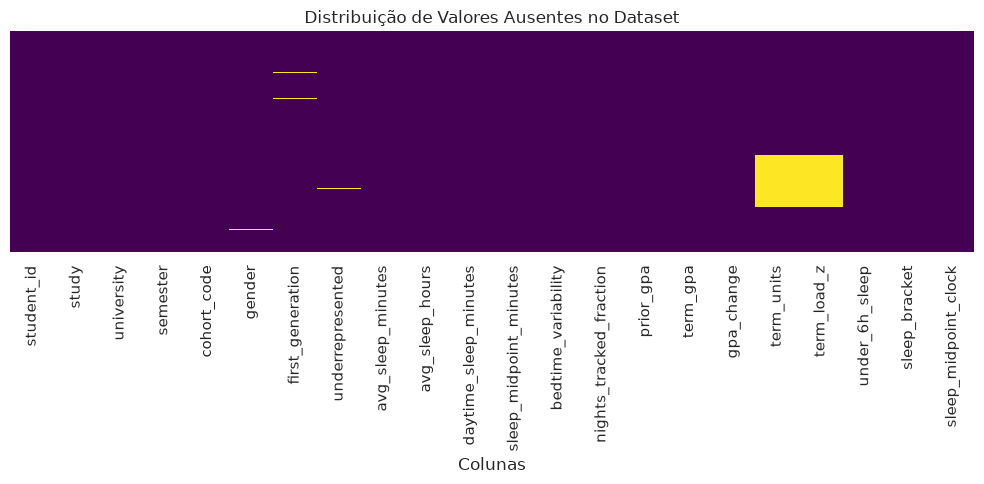

In [262]:
plt.figure(figsize=(10, 5))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Distribuição de Valores Ausentes no Dataset')
plt.xlabel('Colunas')
plt.tight_layout()
plt.show()

/tmp/ipykernel_15663/3094989905.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nulos.index, y=nulos.values, palette='magma')


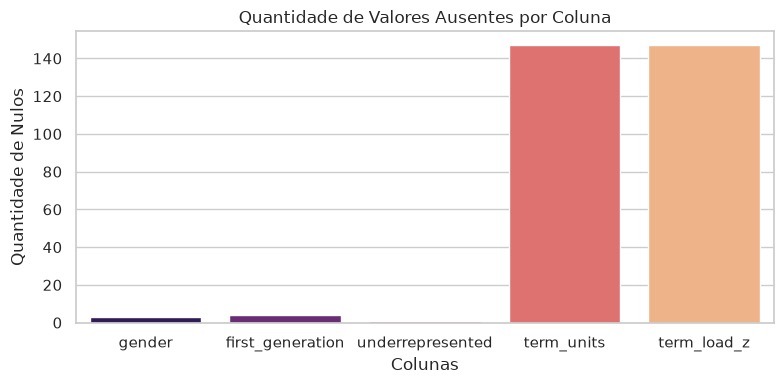

In [263]:
plt.figure(figsize=(8, 4))
sns.barplot(x=nulos.index, y=nulos.values, palette='magma')
plt.title('Quantidade de Valores Ausentes por Coluna')
plt.ylabel('Quantidade de Nulos')
plt.xlabel('Colunas')
plt.tight_layout()
plt.show()

In [264]:
dataLimpo = data.copy()

In [265]:
colInutil = [
    'avg_sleep_minutes',
    'term_units',
    'student_id',
    'sleep_midpoint_clock',
    'cohort_code',
    'study',
    'semester',
]
dataLimpo = dataLimpo.drop(columns=colInutil)

In [266]:
dataLimpo = dataLimpo.dropna(subset=['gender', 'first_generation', 'underrepresented'])

In [267]:
dataLimpo['term_load_z'] = dataLimpo['term_load_z'].fillna(0.0)
print(dataLimpo.isnull().sum())

university                 0
gender                     0
first_generation           0
underrepresented           0
avg_sleep_hours            0
daytime_sleep_minutes      0
sleep_midpoint_minutes     0
bedtime_variability        0
nights_tracked_fraction    0
prior_gpa                  0
term_gpa                   0
gpa_change                 0
term_load_z                0
under_6h_sleep             0
sleep_bracket              0
dtype: int64


In [268]:
colOut = [
    'avg_sleep_hours',
    'daytime_sleep_minutes',
    'sleep_midpoint_minutes',
    'bedtime_variability',
    'prior_gpa',
    'term_gpa',
    'gpa_change',
    'term_load_z'
]

for col in colOut:
    # Garantimos o cálculo dos percentis via NumPy
    Q1 = np.percentile(dataLimpo[col], 25)
    Q3 = np.percentile(dataLimpo[col], 75)
    IQR = Q3 - Q1

    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR

    # Filtra os outliers
    outliers = dataLimpo[(dataLimpo[col] < limite_inf) | (dataLimpo[col] > limite_sup)]
    
    print(f"{col}: {len(outliers)} outliers encontrados.")

avg_sleep_hours: 11 outliers encontrados.
daytime_sleep_minutes: 28 outliers encontrados.
sleep_midpoint_minutes: 15 outliers encontrados.
bedtime_variability: 93 outliers encontrados.
prior_gpa: 17 outliers encontrados.
term_gpa: 21 outliers encontrados.
gpa_change: 43 outliers encontrados.
term_load_z: 53 outliers encontrados.


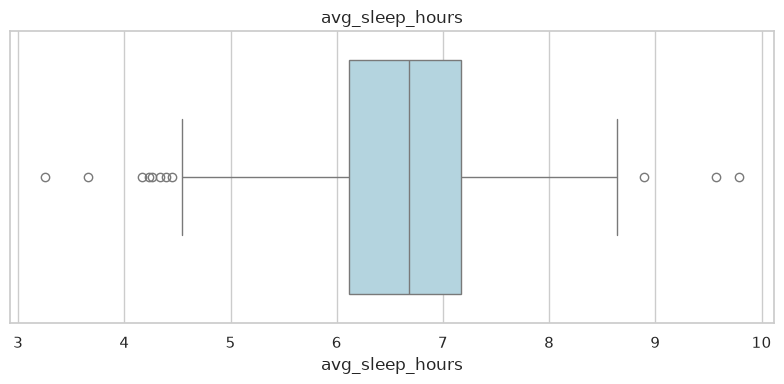

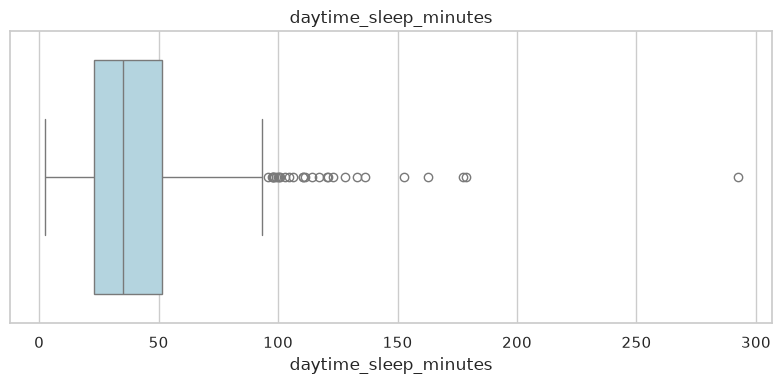

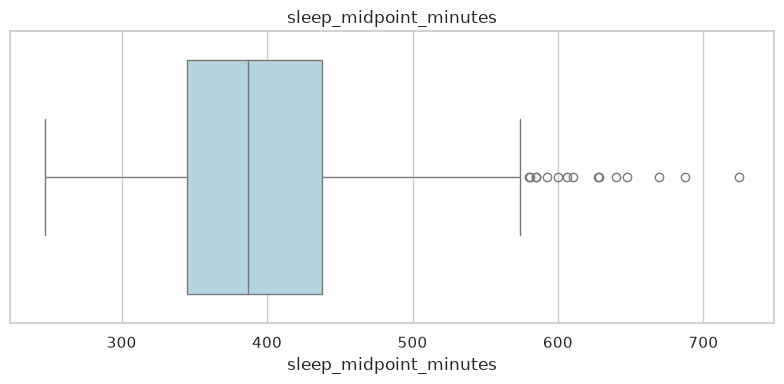

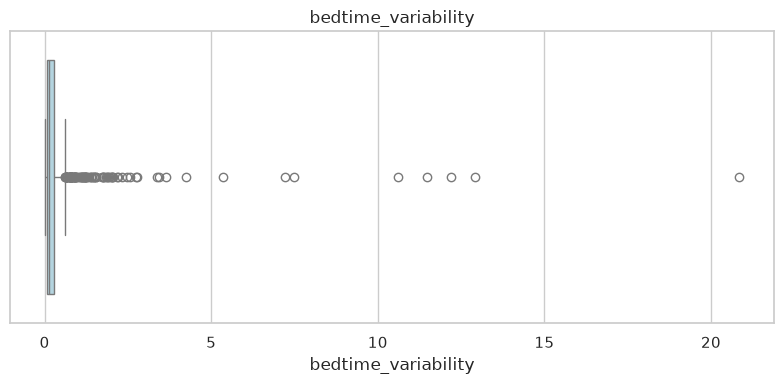

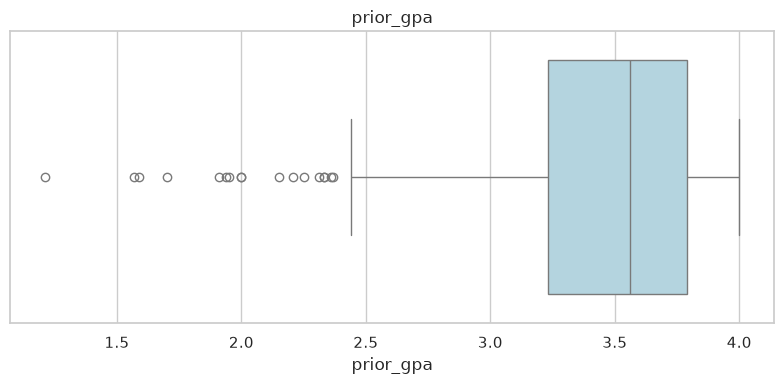

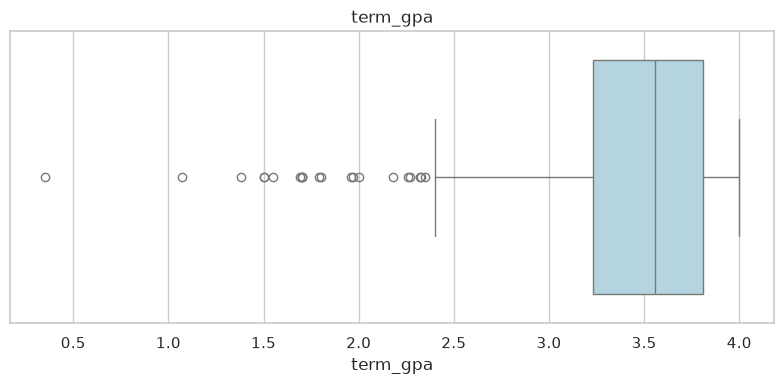

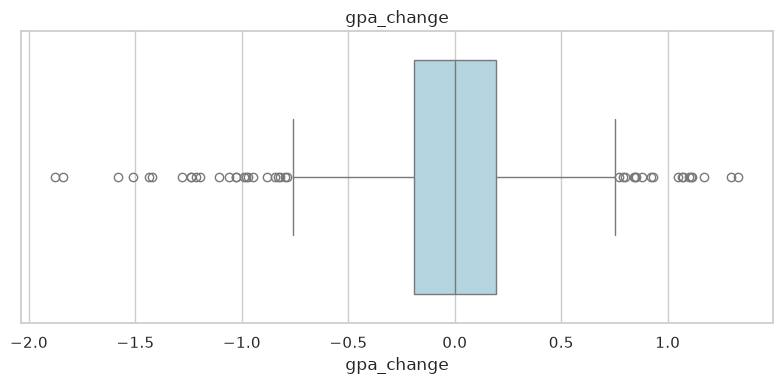

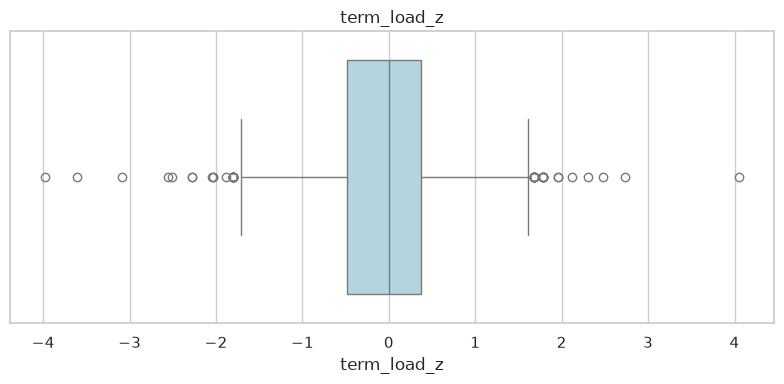

In [269]:
for col in colOut:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=dataLimpo[col], color='lightblue')
    plt.title(col)
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

In [270]:
for col in colOut:
    # 1. Calcular a média e o desvio padrão da coluna
    media = dataLimpo[col].mean()
    desvio = data[col].std()
    
    # 2. Calcular o Z-Score para todos os valores da coluna
    z_scores = (dataLimpo[col] - media) / desvio
    
    # 3. Filtrar onde o Z-Score é maior que 3 (outliers severos)
    outliers = dataLimpo[np.abs(z_scores) > 3]
    
    print(f"=== Coluna: {col} ===")
    print(f"Média: {media:.2f} | Desvio Padrão: {desvio:.2f}")
    print(f"Outliers detectados (|Z| > 3): {len(outliers)}")
    print("-" * 40)

=== Coluna: avg_sleep_hours ===
Média: 6.62 | Desvio Padrão: 0.85
Outliers detectados (|Z| > 3): 4
----------------------------------------
=== Coluna: daytime_sleep_minutes ===
Média: 41.25 | Desvio Padrão: 27.39
Outliers detectados (|Z| > 3): 8
----------------------------------------
=== Coluna: sleep_midpoint_minutes ===
Média: 398.54 | Desvio Padrão: 72.71
Outliers detectados (|Z| > 3): 7
----------------------------------------
=== Coluna: bedtime_variability ===
Média: 0.45 | Desvio Padrão: 1.39
Outliers detectados (|Z| > 3): 8
----------------------------------------
=== Coluna: prior_gpa ===
Média: 3.47 | Desvio Padrão: 0.44
Outliers detectados (|Z| > 3): 10
----------------------------------------
=== Coluna: term_gpa ===
Média: 3.45 | Desvio Padrão: 0.50
Outliers detectados (|Z| > 3): 12
----------------------------------------
=== Coluna: gpa_change ===
Média: -0.02 | Desvio Padrão: 0.40
Outliers detectados (|Z| > 3): 11
----------------------------------------
=== Coluna: 

In [ ]:
colunas_outliers = [
    'avg_sleep_hours', 'daytime_sleep_minutes', 'sleep_midpoint_minutes',
    'bedtime_variability', 'prior_gpa', 'term_gpa', 'gpa_change', 'term_load_z'
]

for col in colunas_outliers:
    if col in dataLimpo.columns:
        Q1 = np.percentile(dataLimpo[col].dropna(), 25)
        Q3 = np.percentile(dataLimpo[col].dropna(), 75)
        IQR = Q3 - Q1
        
        limite_inf = Q1 - 1.5 * IQR
        limite_sup = Q3 + 1.5 * IQR
        
        dataLimpo[col] = np.clip(dataLimpo[col], limite_inf, limite_sup)

print("Capping por IQR concluído com sucesso!")

Capping por IQR concluído com sucesso!


In [272]:
dataEncod = dataLimpo.copy()

In [273]:
brackets = []

for l in dataEncod['sleep_bracket']:
    if l not in brackets:
        brackets.append(l)

print("Brackets únicos encontrados:")
print(brackets)

Brackets únicos encontrados:
['6-6.5h', '6.5-7h', '<5.5h', '5.5-6h', '7-7.5h', '7.5h+']


In [274]:
bracketsEncod = {
    '<5.5h': 1,
    '5.5-6h': 2,
    '6-6.5h': 3,
    '6.5-7h': 4,
    '7-7.5h': 5,
    '7.5h+': 6,
}

dataEncod['sleep_bracket_encoded'] = dataEncod['sleep_bracket'].map(bracketsEncod)
dataEncod = dataEncod.drop(columns=['sleep_bracket'])


In [275]:

dataEncod = pd.get_dummies(dataEncod, columns=['gender', 'university'], drop_first=True, dtype=int)

dataEncod.head()

,first_generation,underrepresented,avg_sleep_hours,daytime_sleep_minutes,sleep_midpoint_minutes,bedtime_variability,nights_tracked_fraction,prior_gpa,term_gpa,gpa_change,term_load_z,under_6h_sleep,sleep_bracket_encoded,gender_Male,university_University of Notre Dame,university_University of Washington
0,0.0,0.0,6.17000,11.700,500.3,0.05000,0.931,4.00,3.76,-0.24,0.1120,0,3,0,0,0
1,0.0,0.0,6.78000,49.700,359.5,0.04760,0.862,4.00,3.55,-0.45,0.1120,0,4,0,0,0
2,0.0,1.0,4.52625,94.125,398.2,0.16390,0.586,3.00,3.59,0.59,-0.6040,1,1,0,0,0
3,0.0,0.0,6.86000,26.100,532.1,0.62075,0.931,3.80,3.46,-0.34,-1.7595,0,4,0,0,0
4,0.0,1.0,6.80000,71.600,354.0,0.15380,0.931,3.17,3.50,0.33,-1.7595,0,4,0,0,0


In [276]:
scaler = StandardScaler()

colunas_continuas = [
    'avg_sleep_hours',
    'daytime_sleep_minutes',
    'sleep_midpoint_minutes',
    'bedtime_variability',
    'nights_tracked_fraction',
    'prior_gpa',
    'gpa_change',
    'term_load_z'
]

dataEncod[colunas_continuas] = scaler.fit_transform(dataEncod[colunas_continuas])

dataEncod.describe()

,first_generation,underrepresented,avg_sleep_hours,daytime_sleep_minutes,sleep_midpoint_minutes,bedtime_variability,nights_tracked_fraction,prior_gpa,term_gpa,gpa_change,term_load_z,under_6h_sleep,sleep_bracket_encoded,gender_Male,university_University of Notre Dame,university_University of Washington
count,626.000000,626.000000,6.260000e+02,6.260000e+02,6.260000e+02,6.260000e+02,6.260000e+02,6.260000e+02,626.000000,6.260000e+02,6.260000e+02,626.000000,626.000000,626.000000,626.000000,626.000000
mean,0.166134,0.188498,-2.951136e-16,-2.043094e-16,2.724126e-16,4.540209e-17,-3.859178e-16,-2.043094e-16,3.469456,-3.405157e-17,-1.986342e-17,0.207668,3.758786,0.418530,0.231629,0.439297
std,0.372499,0.391422,1.000800e+00,1.000800e+00,1.000800e+00,1.000800e+00,1.000800e+00,1.000800e+00,0.436481,1.000800e+00,1.000800e+00,0.405962,1.451386,0.493713,0.422211,0.496698
min,0.000000,0.000000,-2.562262e+00,-1.697405e+00,-2.169875e+00,-1.073336e+00,-3.649348e+00,-2.672607e+00,2.367500,-2.208346e+00,-2.202854e+00,0.000000,1.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,-6.259646e-01,-7.568988e-01,-7.538212e-01,-7.314193e-01,-2.596457e-01,-6.030923e-01,3.233000,-5.326824e-01,-6.039316e-01,0.000000,3.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,6.676914e-02,-2.183377e-01,-1.499318e-01,-4.278370e-01,3.658019e-01,2.076456e-01,3.556000,1.967802e-02,-4.101276e-03,0.000000,4.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,6.649005e-01,5.257123e-01,5.810162e-01,3.510899e-01,7.399536e-01,7.765844e-01,3.810000,5.844265e-01,4.620169e-01,0.000000,5.000000,1.000000,0.000000,1.000000
max,1.000000,1.000000,2.601198e+00,2.449629e+00,2.583272e+00,1.974854e+00,7.399536e-01,1.296050e+00,4.000000,2.260090e+00,2.060940e+00,1.000000,6.000000,1.000000,1.000000,1.000000


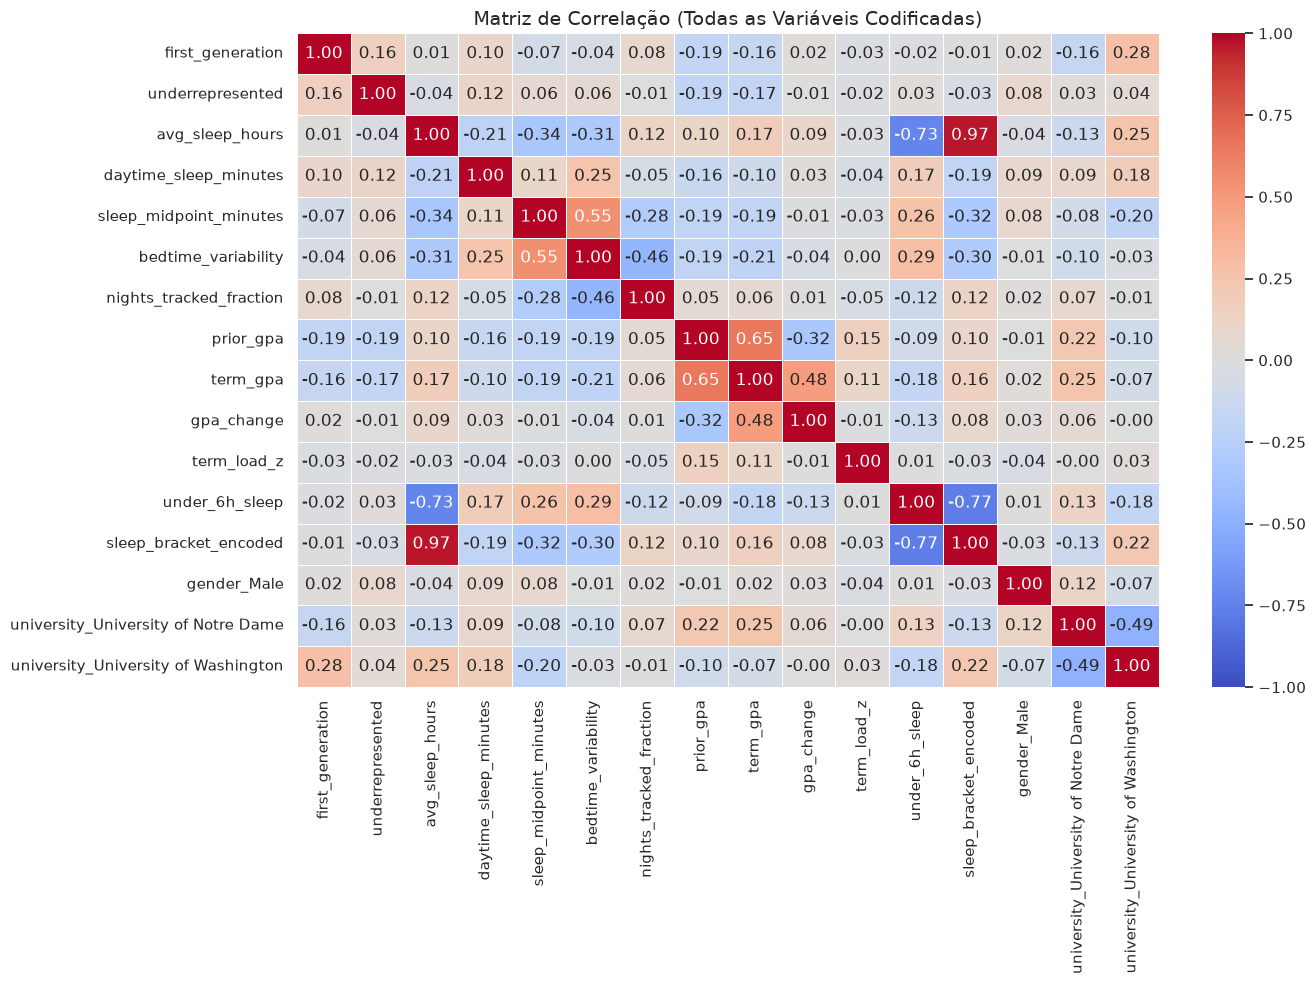

In [277]:
plt.figure(figsize=(14, 10))
matriz_corr = dataEncod.corr()

sns.heatmap(
    matriz_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.title('Matriz de Correlação (Todas as Variáveis Codificadas)', fontsize=14)
plt.tight_layout()
plt.show()

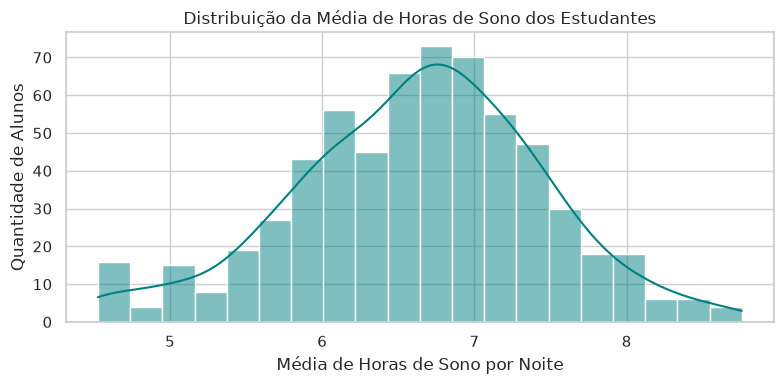

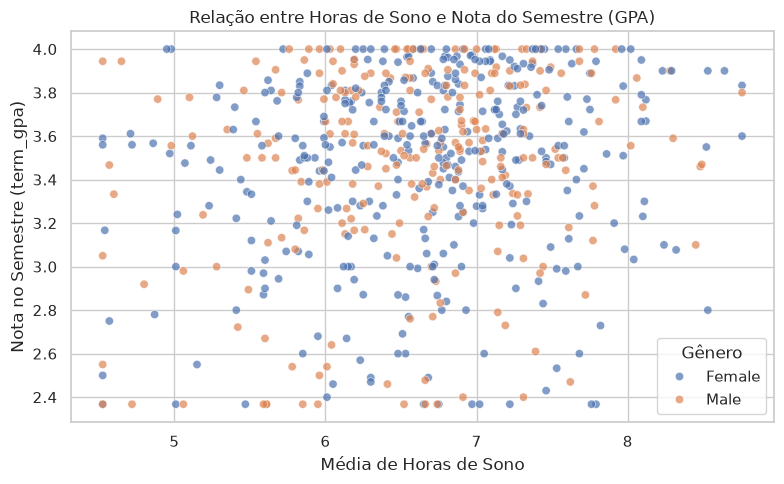

/tmp/ipykernel_15663/54076482.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


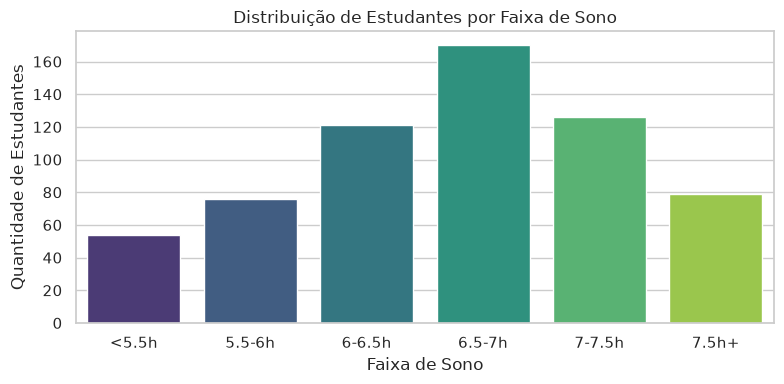

/tmp/ipykernel_15663/54076482.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataLimpo, x='university', y='term_gpa', palette='Set2')


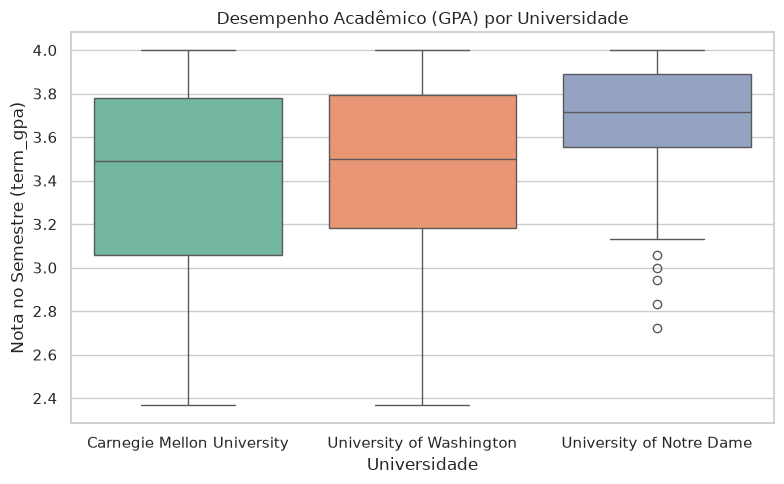

In [278]:


# Configuração de estilo dos gráficos
sns.set_theme(style='whitegrid')

# 1. Histograma: Distribuição de Horas de Sono
plt.figure(figsize=(8, 4))
sns.histplot(data=dataLimpo, x='avg_sleep_hours', kde=True, color='teal', bins=20)
plt.title('Distribuição da Média de Horas de Sono dos Estudantes', fontsize=12)
plt.xlabel('Média de Horas de Sono por Noite')
plt.ylabel('Quantidade de Alunos')
plt.tight_layout()
plt.show()

# 2. Scatterplot: Horas de Sono vs. Nota (GPA) por Gênero
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=dataLimpo,
    x='avg_sleep_hours',
    y='term_gpa',
    hue='gender',
    alpha=0.7
)
plt.title('Relação entre Horas de Sono e Nota do Semestre (GPA)', fontsize=12)
plt.xlabel('Média de Horas de Sono')
plt.ylabel('Nota no Semestre (term_gpa)')
plt.legend(title='Gênero')
plt.tight_layout()
plt.show()

# 3. Countplot: Distribuição de Estudantes por Faixa de Sono
plt.figure(figsize=(8, 4))
sns.countplot(
    data=dataLimpo,
    x='sleep_bracket',
    palette='viridis',
    order=['<5.5h', '5.5-6h', '6-6.5h', '6.5-7h', '7-7.5h', '7.5h+']
)
plt.title('Distribuição de Estudantes por Faixa de Sono', fontsize=12)
plt.xlabel('Faixa de Sono')
plt.ylabel('Quantidade de Estudantes')
plt.tight_layout()
plt.show()

# 4. Boxplot: Desempenho Acadêmico por Universidade
plt.figure(figsize=(8, 5))
sns.boxplot(data=dataLimpo, x='university', y='term_gpa', palette='Set2')
plt.title('Desempenho Acadêmico (GPA) por Universidade', fontsize=12)
plt.xlabel('Universidade')
plt.ylabel('Nota no Semestre (term_gpa)')
plt.tight_layout()
plt.show()